In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn .metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

In [2]:
df1=pd.read_csv(r"C:\Users\27968\Downloads\心血管疾病.csv")

In [3]:
df=df1

In [4]:
df=df[df['ap_lo']<=df['ap_hi']]
height_low = df['height'].quantile(0.02)
height_heigh=df['height'].quantile(0.98)
weight_low = df['weight'].quantile(0.02)
weight_high = df['weight'].quantile(0.98)
df = df[(df['height'] >= height_low) & (df['height'] <= height_heigh)]
df = df[(df['weight'] >= weight_low) & (df['weight'] <= weight_high)]
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,99991,19699,1,172,70.0,130,90,1,1,0,0,1,1
69994,99992,21074,1,165,80.0,150,80,1,1,0,0,1,1
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [5]:
df.to_csv('1.csv', index=False)

In [6]:
df=df.head(1000)

In [7]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089,1516,20472,1,160,74.0,120,80,2,1,0,0,1,0
1090,1517,18165,2,168,92.0,125,80,2,1,0,0,1,0
1091,1518,20550,2,167,63.0,130,90,1,1,0,0,0,0
1093,1520,19765,1,169,66.0,120,80,1,1,0,0,1,0


In [8]:
X = df.drop(columns=['cardio','id'])
y = df['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 自己编写函数

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import confusion_matrix

def my_perceptron_train(X, y, learning_rate=0.01, n_iterations=1000):
    X = np.array(X)
    y = np.array(y)
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0  ##初始化
    for _ in range(n_iterations):
        misclassified = 0
        for idx in range(n_samples):
            linear_output = np.dot(X[idx], weights) + bias
            y_predicted = 1 if linear_output >= 0 else 0
            if y[idx] != y_predicted:
                update = learning_rate * (y[idx] - y_predicted)
                weights += update * X[idx]
                bias += update
                misclassified += 1
        if misclassified == 0:
            break
    return weights, bias

def my_perceptron_predict(X, weights, bias):
    X = np.array(X)
    linear_output = np.dot(X, weights) + bias
    return np.where(linear_output >= 0, 1, 0)


In [11]:
X_train_scaled = np.array(X_train_scaled)
X_test_scaled = np.array(X_test_scaled)
y_train = np.array(y_train)
y_test = np.array(y_test)

weights, bias = my_perceptron_train(X_train_scaled, y_train)
my_pred = my_perceptron_predict(X_test_scaled, weights, bias)

In [12]:
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import confusion_matrix
import pandas as pd

# 训练并预测
sk_perceptron = Perceptron(random_state=42)
sk_perceptron.fit(X_train_scaled, y_train)
sk_pred = sk_perceptron.predict(X_test_scaled)

lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# 计算混淆矩阵
my_conf_matrix = confusion_matrix(y_test, my_pred)
sk_conf_matrix = confusion_matrix(y_test, sk_pred)
lr_conf_matrix = confusion_matrix(y_test, lr_pred)

# 保存预测结果和真实标签
results_df = pd.DataFrame({
    'True_Label': y_test,
    'My_Perceptron_Pred': my_pred,
    'Sklearn_Perceptron_Pred': sk_pred,
    'Logistic_Regression_Pred': lr_pred
})

# 将混淆矩阵结果转换为DataFrame
conf_matrix_results = pd.DataFrame([
    ['My Perceptron'] + my_conf_matrix.flatten().tolist(),
    ['Sklearn Perceptron'] + sk_conf_matrix.flatten().tolist(),
    ['Logistic Regression'] + lr_conf_matrix.flatten().tolist()
], columns=['Model', 'TN', 'FP', 'FN', 'TP'])

In [13]:
with open('2.csv', 'w') as f:
    f.write("Predictions:\n")
    results_df.to_csv(f, index=False)
    f.write("\nConfusion Matrices:\n")
    conf_matrix_results.to_csv(f, index=False)

In [14]:

# 打印混淆矩阵
print("My Perceptron Confusion Matrix:")
print(my_conf_matrix)
print("\nSklearn Perceptron Confusion Matrix:")
print(sk_conf_matrix)
print("\nLogistic Regression Confusion Matrix:")
print(lr_conf_matrix)

My Perceptron Confusion Matrix:
[[52 48]
 [10 90]]

Sklearn Perceptron Confusion Matrix:
[[79 21]
 [37 63]]

Logistic Regression Confusion Matrix:
[[75 25]
 [27 73]]


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {}
for name, pred in [('我的感知机', my_pred), ('Sklearn感知机', sk_pred), ('逻辑回归', lr_pred)]:
    metrics[name] = {
        '准确率': accuracy_score(y_test, pred),
        '精确率': precision_score(y_test, pred),
        '召回率': recall_score(y_test, pred),
        'F1分数': f1_score(y_test, pred)
    }

# 打印评估结果
print("模型评估指标:")
for model, scores in metrics.items():
    print(f"\n{model}:")
    for metric, value in scores.items():
        print(f"{metric}: {value:.4f}")



模型评估指标:

我的感知机:
准确率: 0.7100
精确率: 0.6522
召回率: 0.9000
F1分数: 0.7563

Sklearn感知机:
准确率: 0.7100
精确率: 0.7500
召回率: 0.6300
F1分数: 0.6848

逻辑回归:
准确率: 0.7400
精确率: 0.7449
召回率: 0.7300
F1分数: 0.7374


In [81]:
df10=pd.read_csv(r"D:\Python文件\机器学习与数据挖掘课程\1.csv")

Text(0.5, 1.0, 'Proportion of Smokers vs Non-smokers')

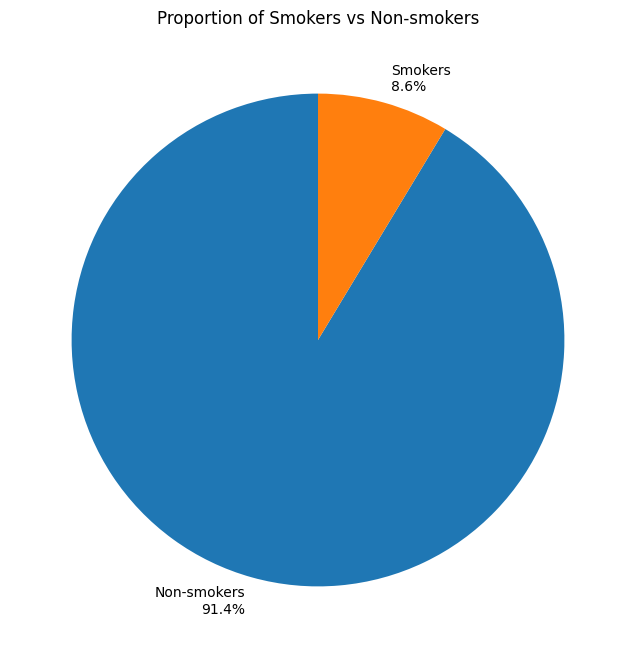

In [83]:
smoke_counts = df10['smoke'].value_counts()
labels = ['Non-smokers', 'Smokers']
sizes = [smoke_counts[0], smoke_counts[1]]

# 计算百分比
total = sum(sizes)
percentages = [size/total*100 for size in sizes]
labels = [f'{labels[i]}\n{percentages[i]:.1f}%' for i in range(len(labels))]

# 创建饼图
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='', startangle=90)
plt.title('Proportion of Smokers vs Non-smokers')
# 保存图片
plt.savefig('1.png')
plt.close()

In [84]:
# 保存图片
plt.savefig('1.png')
plt.close()